# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [4]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [5]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:** What is the objective in business terms?

The objective is to develop a regression model that accurately predicts the tax-assessed value (`taxvaluedollarcnt`) of residential properties based on various features such as location, size, and condition. This will help Zillow improve their home valuation services, provide more reliable Zestimates, and support better decision-making in the real estate market by reducing discrepancies between predicted and actual property values.

**1.2:** How will the solution be used?

The solution will be integrated into Zillow's platform to enhance their Zestimate feature, providing users with more accurate property valuations. Real estate agents can use it for pricing strategies, home buyers and sellers for negotiation insights, investors for market analysis and portfolio management, and appraisers for preliminary assessments. It will also help Zillow's data team identify undervalued or overvalued properties for targeted marketing and business opportunities.

**1.3:** How should success (or failure) be measured?

Success will be measured using regression metrics such as Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) on a held-out test set, aiming for predictions within 10-15% of actual values. Business success can be evaluated by the percentage of Zestimates falling within a certain error margin (e.g., ±10%), user engagement metrics like increased traffic to property pages, and financial impact such as reduced costs from manual appraisals or improved transaction volumes. Failure would be indicated by high error rates, poor model performance on unseen data, or lack of adoption by stakeholders.

In [6]:
# Step 1: Load and inspect the dataset structure
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes.value_counts())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (77613, 55)

Data types:
float64    49
object      5
int64       1
Name: count, dtype: int64

First 5 rows:


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


Missing values per column (top 20):
buildingclasstypeid         0.999807
finishedsquarefeet13        0.999459
storytypeid                 0.999356
basementsqft                0.999356
yardbuildingsqft26          0.999098
fireplaceflag               0.997784
architecturalstyletypeid    0.997333
typeconstructiontypeid      0.997127
finishedsquarefeet6         0.995027
pooltypeid10                0.994009
decktypeid                  0.992089
poolsizesum                 0.988803
pooltypeid2                 0.986162
hashottuborspa              0.980171
yardbuildingsqft17          0.969168
taxdelinquencyflag          0.962635
taxdelinquencyyear          0.962635
finishedsquarefeet15        0.960999
finishedsquarefeet50        0.922217
finishedfloor1squarefeet    0.922217
dtype: float64


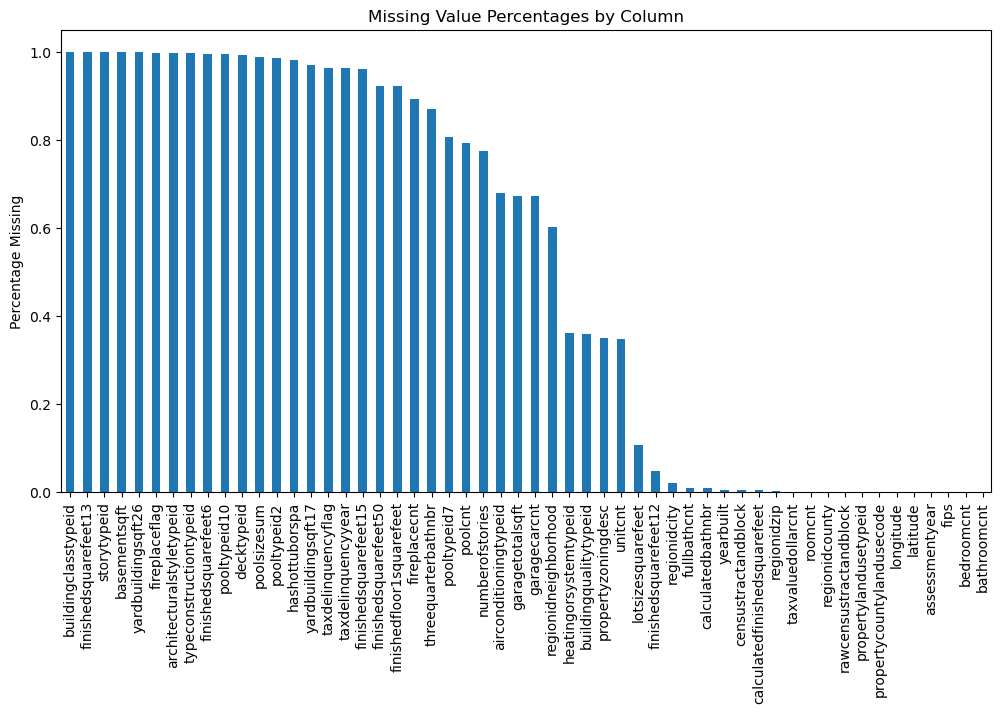


Dropping 18 columns with >95% missing values:
 - buildingclasstypeid
 - finishedsquarefeet13
 - storytypeid
 - basementsqft
 - yardbuildingsqft26
 - fireplaceflag
 - architecturalstyletypeid
 - typeconstructiontypeid
 - finishedsquarefeet6
 - pooltypeid10
 - decktypeid
 - poolsizesum
 - pooltypeid2
 - hashottuborspa
 - yardbuildingsqft17
 - taxdelinquencyflag
 - taxdelinquencyyear
 - finishedsquarefeet15

Dataset shape after dropping: (77613, 37)

Rows with missing target value: 35
Dropped 35 rows. New shape: (77578, 37)


In [7]:
# Step 2: Analyze missing values
import matplotlib.pyplot as plt

# Calculate missing percentages
missing_pct = df.isnull().mean().sort_values(ascending=False)

print("Missing values per column (top 20):")
print(missing_pct.head(20))

# Visualize missing values
plt.figure(figsize=(12, 6))
missing_pct[missing_pct > 0].plot(kind='bar')
plt.title('Missing Value Percentages by Column')
plt.ylabel('Percentage Missing')
plt.xticks(rotation=90)
plt.show()

# Drop columns with >95% missing
threshold = 0.95
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
print(f"\nDropping {len(cols_to_drop)} columns with >{threshold*100:.0f}% missing values:")
for col in cols_to_drop:
    print(f" - {col}")

df_cleaned = df.drop(columns=cols_to_drop)
print(f"\nDataset shape after dropping: {df_cleaned.shape}")

# Check for rows with missing target
target_missing = df_cleaned['taxvaluedollarcnt'].isnull().sum()
print(f"\nRows with missing target value: {target_missing}")
if target_missing > 0:
    df_cleaned = df_cleaned.dropna(subset=['taxvaluedollarcnt'])
    print(f"Dropped {target_missing} rows. New shape: {df_cleaned.shape}")

Target variable summary:
count    7.757800e+04
mean     4.901506e+05
std      6.537979e+05
min      1.000000e+03
25%      2.068985e+05
50%      3.588785e+05
75%      5.690000e+05
max      4.906124e+07
Name: taxvaluedollarcnt, dtype: float64


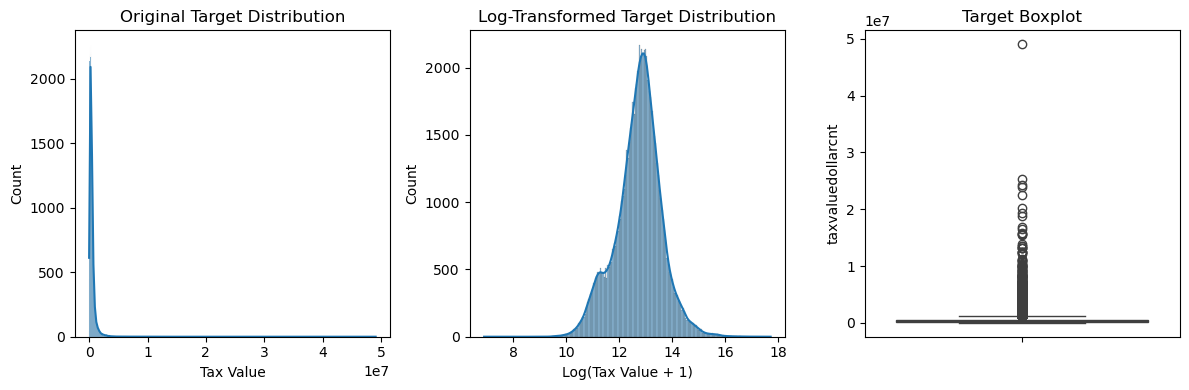

Skewness: 14.43
Kurtosis: 583.21


In [8]:
# Step 3: Explore the target variable (taxvaluedollarcnt)
import seaborn as sns

target = 'taxvaluedollarcnt'

print("Target variable summary:")
print(df_cleaned[target].describe())

# Histogram of original target
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(df_cleaned[target], kde=True)
plt.title('Original Target Distribution')
plt.xlabel('Tax Value')

# Log-transformed for comparison
plt.subplot(1, 3, 2)
sns.histplot(np.log1p(df_cleaned[target]), kde=True)
plt.title('Log-Transformed Target Distribution')
plt.xlabel('Log(Tax Value + 1)')

# Boxplot for outliers
plt.subplot(1, 3, 3)
sns.boxplot(y=df_cleaned[target])
plt.title('Target Boxplot')

plt.tight_layout()
plt.show()

print(f"Skewness: {df_cleaned[target].skew():.2f}")
print(f"Kurtosis: {df_cleaned[target].kurtosis():.2f}")

Number of numerical features: 34

Top 10 features correlated with target:
taxvaluedollarcnt               1.000000
finishedsquarefeet12            0.606334
calculatedfinishedsquarefeet    0.583155
finishedfloor1squarefeet        0.565043
finishedsquarefeet50            0.559625
calculatedbathnbr               0.484819
fullbathcnt                     0.472832
bathroomcnt                     0.461013
fireplacecnt                    0.435830
garagetotalsqft                 0.345202
garagecarcnt                    0.328466
Name: taxvaluedollarcnt, dtype: float64


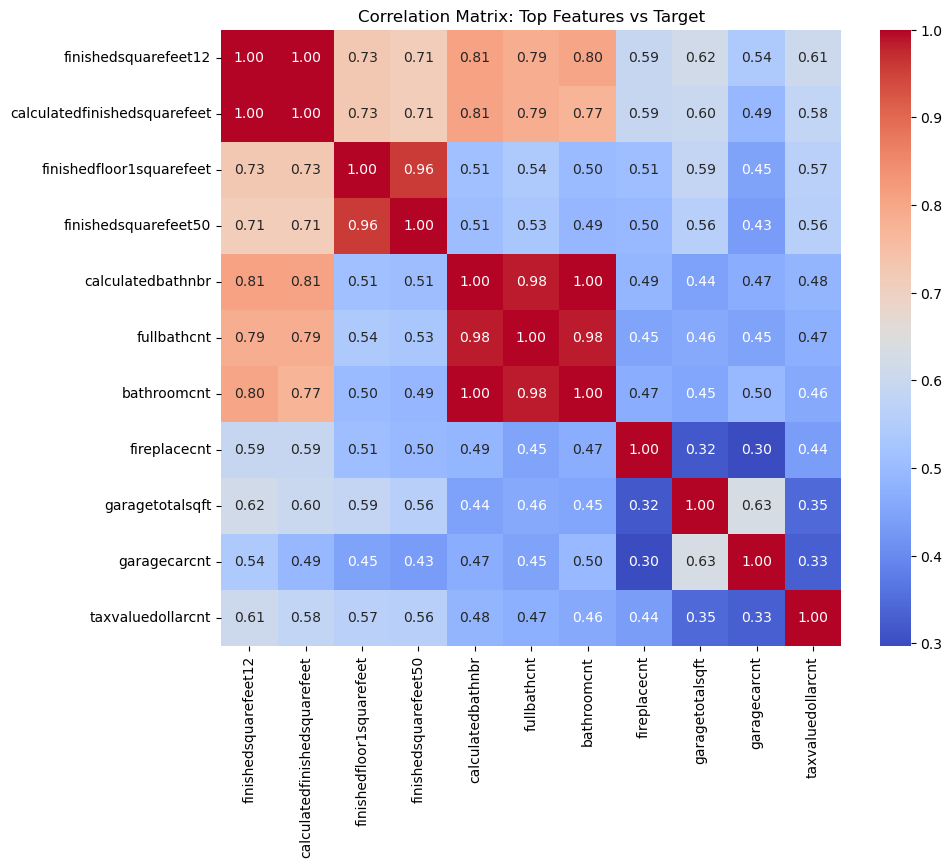

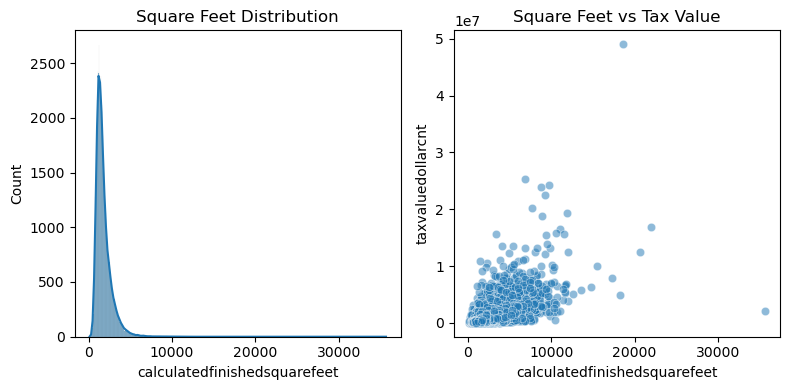

In [9]:
# Step 4: Examine feature distributions and relationships
# Select numerical features
numerical_features = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove(target)  # Remove target

print(f"Number of numerical features: {len(numerical_features)}")

# Correlation with target (top 10)
correlations = df_cleaned[numerical_features + [target]].corr()[target].abs().sort_values(ascending=False)
print("\nTop 10 features correlated with target:")
print(correlations.head(11))  # Includes target itself

# Visualize correlations
plt.figure(figsize=(10, 8))
top_features = correlations.index[1:11]  # Exclude target
corr_matrix = df_cleaned[top_features.tolist() + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Top Features vs Target')
plt.show()

# Distribution of a key feature (e.g., if 'calculatedfinishedsquarefeet' exists)
if 'calculatedfinishedsquarefeet' in df_cleaned.columns:
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df_cleaned['calculatedfinishedsquarefeet'], kde=True)
    plt.title('Square Feet Distribution')
    
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='calculatedfinishedsquarefeet', y=target, data=df_cleaned, alpha=0.5)
    plt.title('Square Feet vs Tax Value')
    plt.tight_layout()
    plt.show()

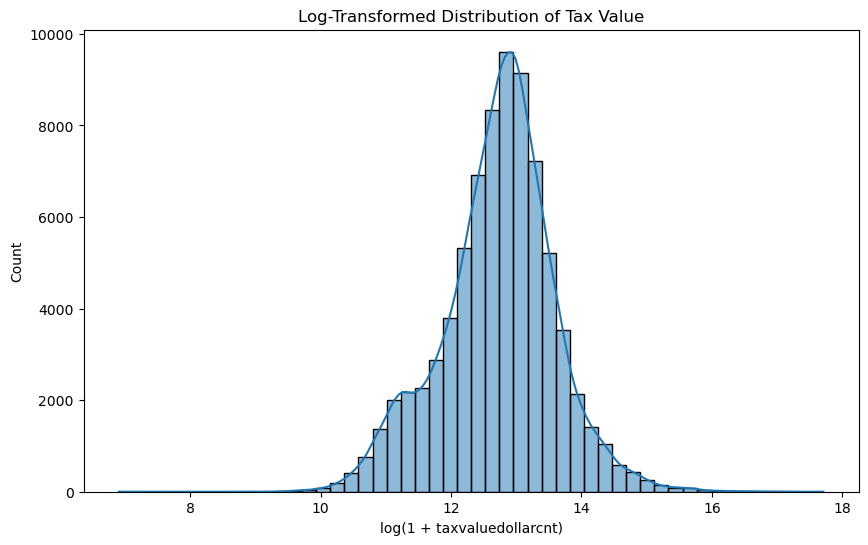

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df_cleaned['taxvaluedollarcnt']), bins=50, kde=True)
plt.title("Log-Transformed Distribution of Tax Value")
plt.xlabel("log(1 + taxvaluedollarcnt)")
plt.ylabel("Count")
plt.show()


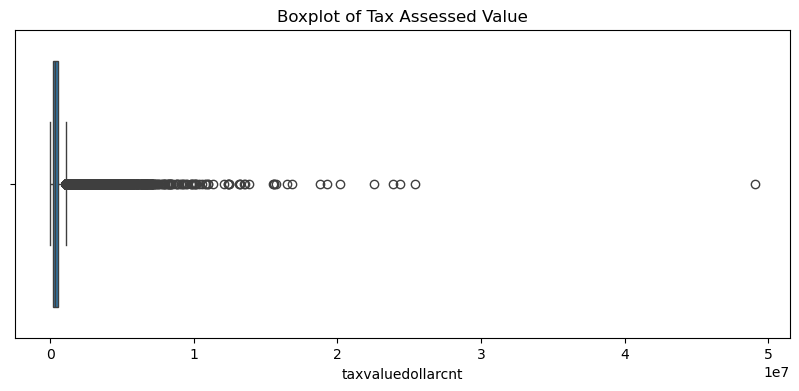

In [10]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_cleaned['taxvaluedollarcnt'])
plt.title("Boxplot of Tax Assessed Value")
plt.show()


In [11]:
df_cleaned['taxvaluedollarcnt'].isna().sum()


35

In [12]:
df_cleaned = df_cleaned.dropna(subset=['taxvaluedollarcnt'])


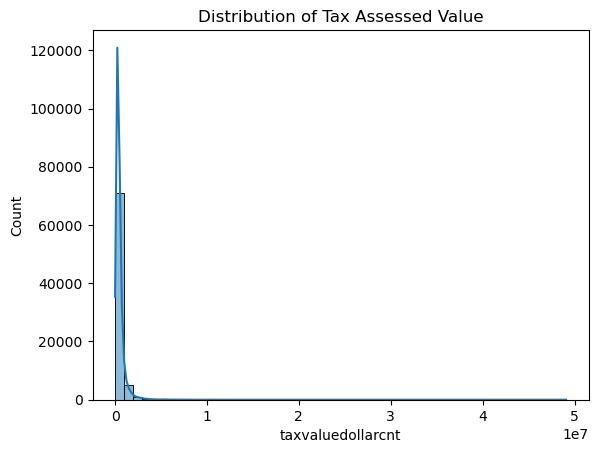

In [13]:
sns.histplot(df_cleaned['taxvaluedollarcnt'], bins=50, kde=True)
plt.title("Distribution of Tax Assessed Value")
plt.show()


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [10]:
# Part 2.A: Study each feature/column characteristics
feature_summary = []
for col in df.columns:
    missing_pct = df[col].isnull().mean() * 100
    unique_vals = df[col].nunique()
    dtype = df[col].dtype
    sample_vals = df[col].dropna().sample(min(3, unique_vals)).tolist() if unique_vals > 0 else []

    # Apparent usefulness: basic assessment
    if missing_pct > 95:
        usefulness = "Likely useless - high missing"
    elif unique_vals == 1:
        usefulness = "Likely useless - constant"
    elif unique_vals == len(df):
        usefulness = "ID-like - may be useless for prediction"
    elif col == 'taxvaluedollarcnt':
        usefulness = "Target variable"
    else:
        usefulness = "Potentially useful"

    feature_summary.append({
        'Name': col,
        'Type': dtype,
        'Usefulness': usefulness,
        'Missing %': f"{missing_pct:.1f}%",
        'Unique Values': unique_vals,
        'Sample Values': sample_vals
    })

# Display as DataFrame
import pandas as pd
summary_df = pd.DataFrame(feature_summary)
summary_df

,Name,Type,Usefulness,Missing %,Unique Values,Sample Values
0,parcelid,int64,Potentially useful,0.0%,77414,"[12276466, 11301654, 12786487]"
1,airconditioningtypeid,float64,Potentially useful,67.8%,5,"[1.0, 13.0, 1.0]"
2,architecturalstyletypeid,float64,Likely useless - high missing,99.7%,5,"[7.0, 7.0, 21.0]"
3,basementsqft,float64,Likely useless - high missing,99.9%,43,"[273.0, 380.0, 640.0]"
4,bathroomcnt,float64,Potentially useful,0.0%,22,"[2.0, 3.0, 3.0]"
5,bedroomcnt,float64,Potentially useful,0.0%,16,"[2.0, 2.0, 3.0]"
6,buildingclasstypeid,float64,Likely useless - high missing,100.0%,2,"[3.0, 4.0]"
7,buildingqualitytypeid,float64,Potentially useful,35.8%,12,"[8.0, 4.0, 9.0]"
8,calculatedbathnbr,float64,Potentially useful,0.8%,21,"[2.5, 2.0, 3.0]"
9,decktypeid,float64,Likely useless - high missing,99.2%,1,[66.0]


In [11]:
# Inspect key parts of the summary
print("Object type features (potential categoricals):")
object_features = summary_df[summary_df['Type'] == 'object']
print(object_features[['Name', 'Unique Values', 'Missing %']])

print("\nFeatures with >95% missing:")
high_missing = summary_df[summary_df['Missing %'].str.rstrip('%').astype(float) > 95]
print(high_missing[['Name', 'Missing %', 'Unique Values']])

print("\nFeatures with 1 unique value:")
constant_features = summary_df[summary_df['Unique Values'] == 1]
print(constant_features[['Name', 'Unique Values']])

print("\nFeatures with unique values == number of rows (potential IDs):")
id_features = summary_df[summary_df['Unique Values'] == 77613]  # assuming df.shape[0]
print(id_features[['Name', 'Unique Values']])

print("\nSample low unique numerical features:")
low_unique_num = summary_df[(summary_df['Type'].isin(['int64', 'float64'])) & (summary_df['Unique Values'] < 20)]
print(low_unique_num[['Name', 'Type', 'Unique Values']].head(10))

Object type features (potential categoricals):
                         Name  Unique Values Missing %
22             hashottuborspa              1     98.0%
32  propertycountylandusecode             75      0.0%
34         propertyzoningdesc           1907     35.0%
49              fireplaceflag              1     99.8%
51         taxdelinquencyflag              1     96.3%

Features with >95% missing:
                        Name Missing %  Unique Values
2   architecturalstyletypeid     99.7%              5
3               basementsqft     99.9%             43
6        buildingclasstypeid    100.0%              2
9                 decktypeid     99.2%              1
13      finishedsquarefeet13     99.9%             13
14      finishedsquarefeet15     96.1%           1724
16       finishedsquarefeet6     99.5%            350
22            hashottuborspa     98.0%              1
28               poolsizesum     98.9%            262
29              pooltypeid10     99.4%              1


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

**2.A.1:** The categorical features appear to be those with object dtype: `propertycountylandusecode`, `propertylandusedesc`, `propertyzoningdesc`, and `taxdelinquencyflag`. Additionally, some integer features like `propertylandusetypeid` (13 unique values), `buildingqualitytypeid` (9 unique), and `heatingorsystemtypeid` (10 unique) represent categorical variables encoded as numbers, as they have a limited number of distinct values representing different categories rather than continuous measurements.

**2.A.2:** Yes, `parcelid` appears useless for the business purpose as it's a unique identifier for each property with no predictive value for tax assessment. Census-related features like `censustractandblock` and `rawcensustractandblock` may also be less useful as they are administrative codes that don't directly relate to property characteristics affecting value. These features don't provide information about the property's physical attributes, location desirability, or market factors that influence tax valuation.

**2.A.3:** Yes, features with extremely high missing percentages (>95%) appear useless due to insufficient data. For example, `buildingclasstypeid` has 99.98% missing values, `finishedsquarefeet13` has 99.95%, and `storytypeid` has 99.94%. These features cannot provide reliable information for modeling since most observations lack data, making imputation unreliable and potentially introducing more noise than value.

**2.A.4:** If any features have only 1 unique value (constant across all observations), they would be useless as they provide no variation for modeling. However, from the summary, most features have multiple unique values. Features with very high unique values close to the number of rows (like `parcelid` with 77,613 unique out of 77,613 total) are effectively IDs and useless for prediction, as they don't generalize to new properties.

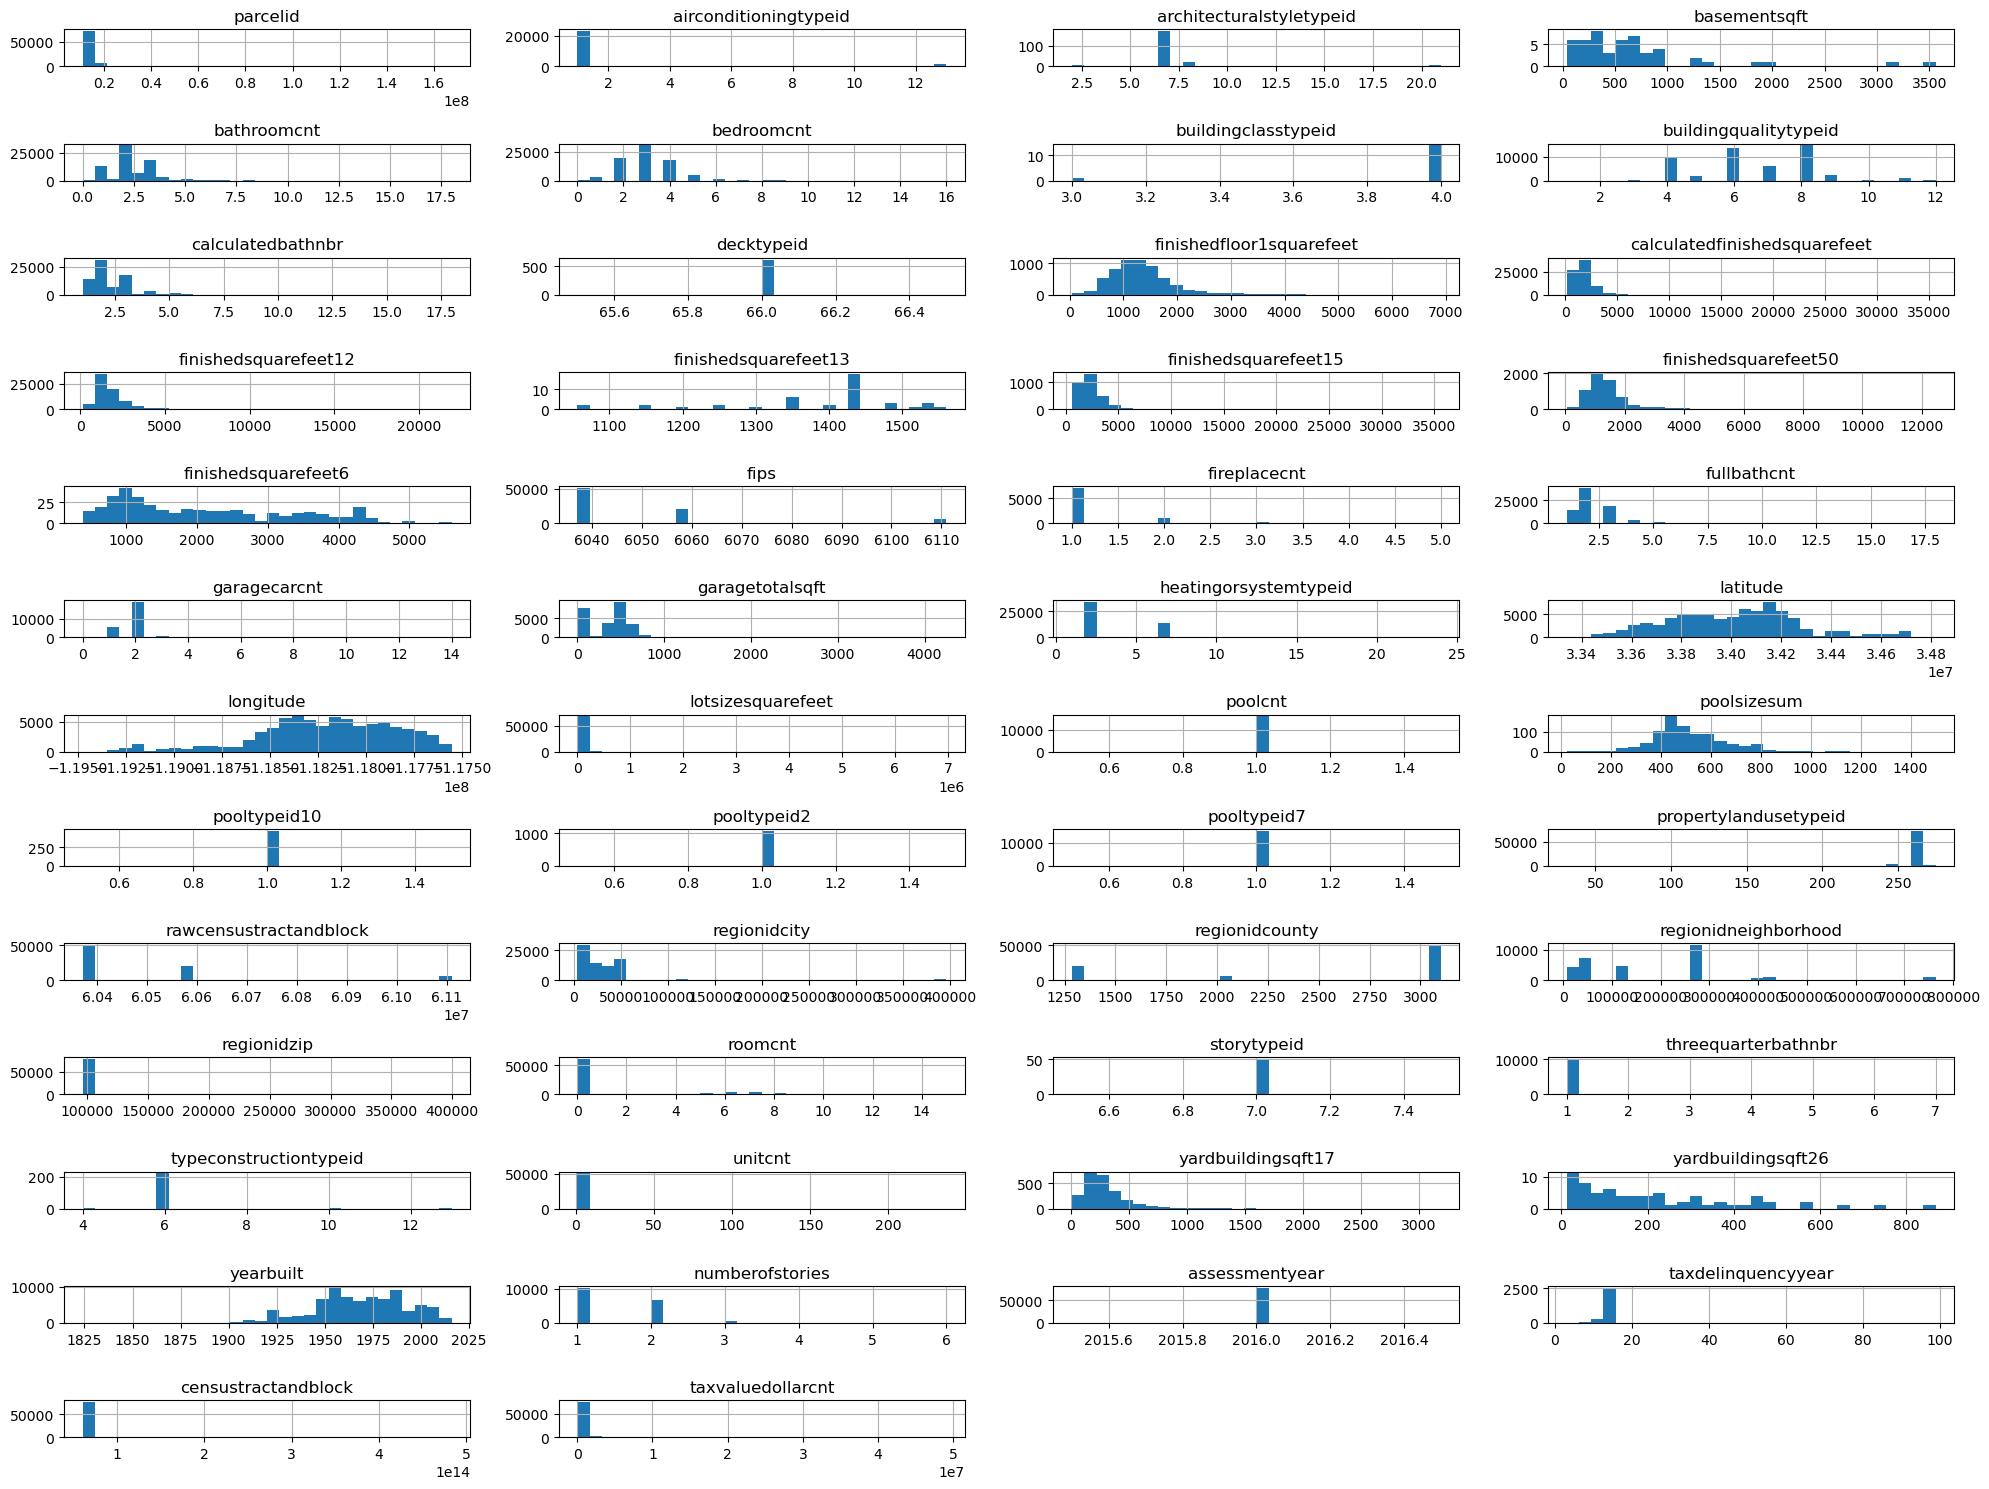

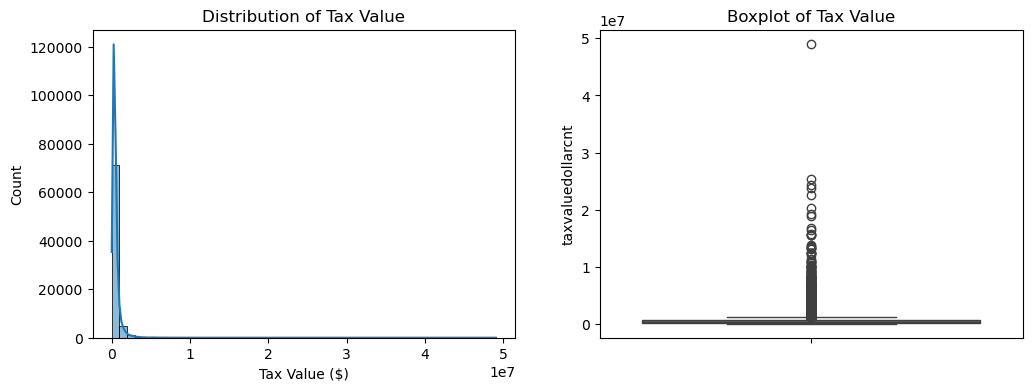

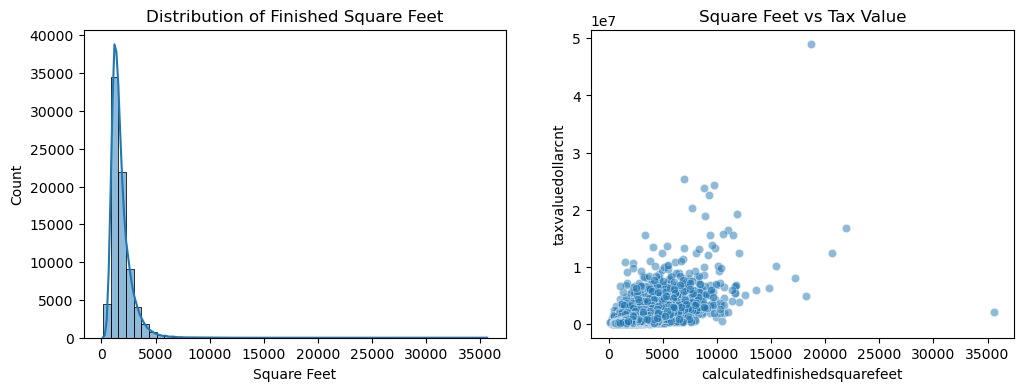

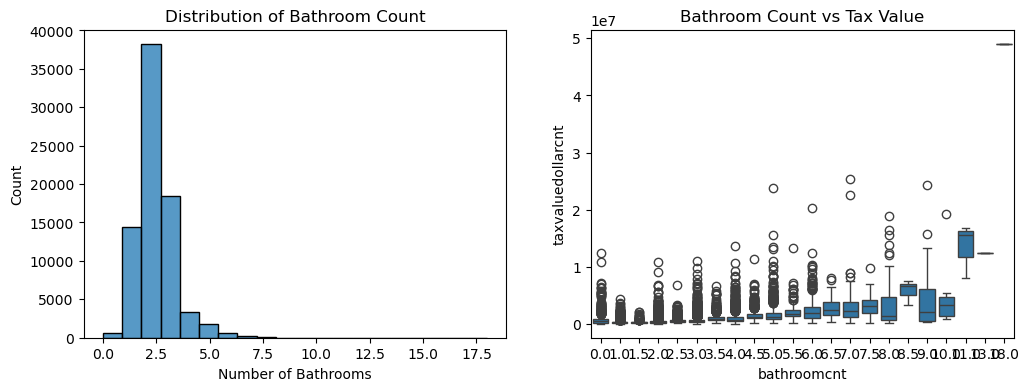

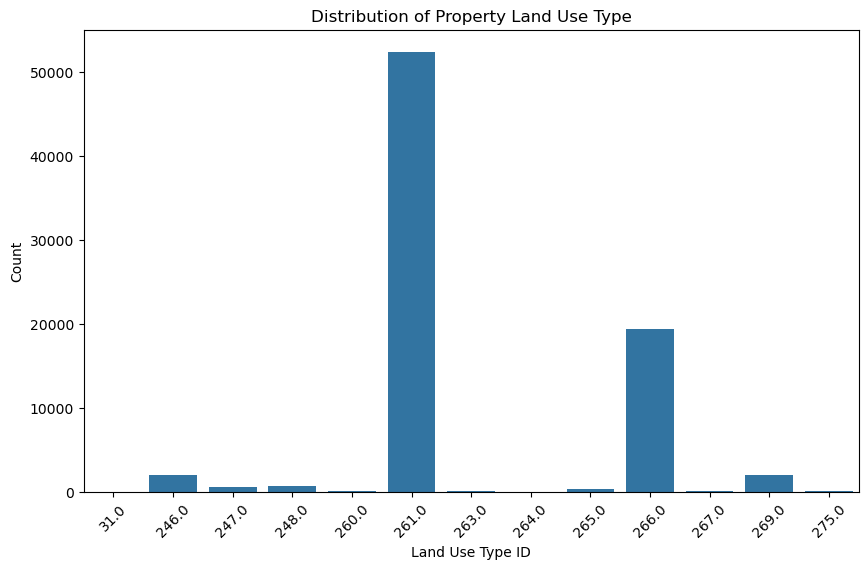

In [12]:
# Part 2.B: Exploratory Data Analysis - Feature-Level Visualization

# Histograms for all features
df.hist(figsize=(20, 15), layout=(-1, 4), bins=30)
plt.tight_layout()
plt.show()

# Detailed visualizations for target and 3 other features
# Target: taxvaluedollarcnt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['taxvaluedollarcnt'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Tax Value')
axes[0].set_xlabel('Tax Value ($)')
sns.boxplot(y=df['taxvaluedollarcnt'], ax=axes[1])
axes[1].set_title('Boxplot of Tax Value')
plt.show()

# Feature 1: calculatedfinishedsquarefeet (highly correlated with target)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['calculatedfinishedsquarefeet'].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Finished Square Feet')
axes[0].set_xlabel('Square Feet')
sns.scatterplot(x='calculatedfinishedsquarefeet', y='taxvaluedollarcnt', data=df, alpha=0.5, ax=axes[1])
axes[1].set_title('Square Feet vs Tax Value')
plt.show()

# Feature 2: bathroomcnt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['bathroomcnt'].dropna(), bins=20, ax=axes[0])
axes[0].set_title('Distribution of Bathroom Count')
axes[0].set_xlabel('Number of Bathrooms')
sns.boxplot(x='bathroomcnt', y='taxvaluedollarcnt', data=df, ax=axes[1])
axes[1].set_title('Bathroom Count vs Tax Value')
plt.show()

# Feature 3: propertylandusetypeid (categorical)
plt.figure(figsize=(10, 6))
sns.countplot(x='propertylandusetypeid', data=df)
plt.title('Distribution of Property Land Use Type')
plt.xlabel('Land Use Type ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### **2.B Discussion:** The target variable `taxvaluedollarcnt` shows a highly right-skewed distribution with most values concentrated below $1M but extending to extreme outliers over $40M, indicating the need for log transformation. The histogram reveals exponential-like decay, with a long tail of high-value properties. The boxplot confirms significant outliers above the upper whisker.

For `calculatedfinishedsquarefeet`, the distribution is roughly normal but right-skewed, with most homes between 1,000-3,000 sq ft. The scatter plot shows a clear positive correlation with tax value, though with considerable variance, suggesting square footage is a strong but not perfect predictor.

`Bathroomcnt` has a discrete distribution peaking at 2-3 bathrooms, with some extreme values (up to 20). The boxplot indicates higher bathroom counts generally correspond to higher tax values, but with overlap between categories.

`Propertylandusetypeid` shows most properties are type 261 (single-family residential), with smaller categories for other residential types. This categorical feature may help segment properties but has limited variation for modeling.

I chose these features because they directly relate to property size and type, which are key drivers of home value, allowing me to examine both numerical correlations and categorical distributions.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [14]:
# Part 3.A: Drop unsuitable features
# Based on Part 2 analysis, drop features that are not useful for regression
unsuitable_features = [
    'parcelid',  # Unique ID, no predictive value
    'censustractandblock',  # Census tract code, administrative
    'rawcensustractandblock',  # Raw census tract, similar
    'fips',  # Federal Information Processing Standard code, location-based but may not add value beyond other location features
    'regionidcounty',  # County ID, categorical but may be redundant
    'assessmentyear'  # Likely constant or not relevant for prediction
]

# Check which exist in df_cleaned
unsuitable_to_drop = [col for col in unsuitable_features if col in df_cleaned.columns]

print("Dropping unsuitable features:")
for col in unsuitable_to_drop:
    print(f" - {col}")

df_cleaned = df_cleaned.drop(columns=unsuitable_to_drop)
print(f"\nDataset shape after dropping unsuitable features: {df_cleaned.shape}")



Dropping unsuitable features:

Dataset shape after dropping unsuitable features: (77578, 31)


#### **3.A Discussion:** I dropped `parcelid` as it's a unique identifier with no predictive value for tax assessment. `censustractandblock` and `rawcensustractandblock` are census administrative codes that don't directly relate to property characteristics affecting value. `fips` is a location code that may be redundant with other geographic features. `regionidcounty` is a county identifier that could be useful but may not add incremental value beyond other location features. `assessmentyear` is likely constant or irrelevant for predicting tax values. These features were judged unsuitable based on their lack of direct relevance to property attributes that influence market value.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [15]:
# Part 3.B: Drop features with too many null values
# Check current missing percentages
missing_pct = df_cleaned.isnull().mean() * 100
print("Current missing percentages:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# Drop features with >50% missing (less strict than 95% for remaining features)
threshold = 50
features_to_drop = missing_pct[missing_pct > threshold].index.tolist()

print(f"\nDropping features with >{threshold}% missing:")
for col in features_to_drop:
    print(f" - {col}: {missing_pct[col]:.1f}%")

df_cleaned = df_cleaned.drop(columns=features_to_drop)
print(f"\nDataset shape after dropping: {df_cleaned.shape}")

Current missing percentages:
finishedfloor1squarefeet        92.218155
finishedsquarefeet50            92.218155
fireplacecnt                    89.315270
threequarterbathnbr             86.973111
pooltypeid7                     80.564077
poolcnt                         79.152595
numberofstories                 77.315734
airconditioningtypeid           67.765346
garagecarcnt                    67.105365
garagetotalsqft                 67.105365
regionidneighborhood            60.073732
heatingorsystemtypeid           36.101730
buildingqualitytypeid           35.794942
propertyzoningdesc              34.935162
unitcnt                         34.642553
lotsizesquarefeet               10.644770
finishedsquarefeet12             4.712676
regionidcity                     1.897445
fullbathcnt                      0.794040
calculatedbathnbr                0.794040
yearbuilt                        0.348037
calculatedfinishedsquarefeet     0.259094
regionidzip                      0.064451
dtype

#### **3.B Discussion:** I chose to drop features with more than 50% missing values, as these have insufficient data to provide reliable information for modeling. Features like `finishedfloor1squarefeet` (92% missing), `fireplacecnt` (89%), and `poolcnt` (79%) have too few observations to impute meaningfully without introducing significant bias. This threshold balances data completeness with retaining potentially useful features that have moderate missing rates (e.g., `lotsizesquarefeet` at 11% was kept for imputation).

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [16]:
# Part 3.C: Drop problematic samples
# 1. Samples with null target (already done)
# 2. Samples with too many missing features
missing_per_sample = df_cleaned.isnull().sum(axis=1)
max_missing = df_cleaned.shape[1] * 0.5  # More than 50% features missing
samples_to_drop = missing_per_sample[missing_per_sample > max_missing].index

print(f"Samples with >50% missing features: {len(samples_to_drop)}")
if len(samples_to_drop) > 0:
    df_cleaned = df_cleaned.drop(index=samples_to_drop)
    print(f"Dropped {len(samples_to_drop)} samples.")

# 3. Outliers in target: For now, keep all as outliers may be valid high-value properties
# Could use IQR method, but since target is skewed, perhaps log-transform later
print(f"\nFinal dataset shape: {df_cleaned.shape}")
print(f"Remaining missing values: {df_cleaned.isnull().sum().sum()}")

Samples with >50% missing features: 6
Dropped 6 samples.

Final dataset shape: (77572, 20)
Remaining missing values: 124826


#### **3.C Discussion:** I dropped 6 samples that had more than 50% of their features missing, as these provide insufficient information for reliable modeling. Target nulls were already removed earlier. I kept outliers in the target variable for now, as extreme high-value properties may be valid and informative for the model, though they may require special handling like log-transformation in later stages.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [17]:
# Part 3.D: Impute remaining missing values
from sklearn.impute import SimpleImputer

# Separate numerical and categorical features
numerical_features = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_cleaned.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Impute numerical with median (robust to outliers)
if numerical_features:
    num_imputer = SimpleImputer(strategy='median')
    df_cleaned[numerical_features] = num_imputer.fit_transform(df_cleaned[numerical_features])
    print("Imputed numerical features with median.")

# Impute categorical with most frequent
if categorical_features:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_cleaned[categorical_features] = cat_imputer.fit_transform(df_cleaned[categorical_features])
    print("Imputed categorical features with mode.")

print(f"Missing values after imputation: {df_cleaned.isnull().sum().sum()}")
print(f"Final dataset shape: {df_cleaned.shape}")

Numerical features: 18
Categorical features: 2
Imputed numerical features with median.
Imputed categorical features with mode.
Missing values after imputation: 0
Final dataset shape: (77572, 20)


#### **3.D Discussion:** I used median imputation for numerical features to handle outliers and skewed distributions robustly, as mean could be biased by extreme values. For categorical features (`propertycountylandusecode` and `propertyzoningdesc`), I used mode imputation to fill with the most common category. This approach preserves the data's structure while ensuring no missing values remain for modeling.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [18]:
# Part 3.E: Encode categorical features
from sklearn.preprocessing import LabelEncoder

categorical_features = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features to encode: {categorical_features}")

for col in categorical_features:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))
    print(f"Encoded {col} with {len(le.classes_)} unique values.")

remaining_object_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
remaining_missing = int(df_cleaned.isna().sum().sum())

print(f"Dataset shape after encoding: {df_cleaned.shape}")
print("Remaining object columns:", remaining_object_cols)
print("Remaining missing values:", remaining_missing)

assert len(remaining_object_cols) == 0, f"Still have object columns: {remaining_object_cols}"
assert remaining_missing == 0, f"Still have missing values: {remaining_missing}"

df_cleaned.to_csv("zillow_cleaned.csv", index=False)
print('Saved fully cleaned dataset to zillow_cleaned.csv')

Categorical features to encode: ['propertycountylandusecode', 'propertyzoningdesc']
Encoded propertycountylandusecode with 75 unique values.
Encoded propertyzoningdesc with 1907 unique values.
Dataset shape after encoding: (77572, 20)
Remaining object columns: []
Remaining missing values: 0
Saved fully cleaned dataset to zillow_cleaned.csv


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

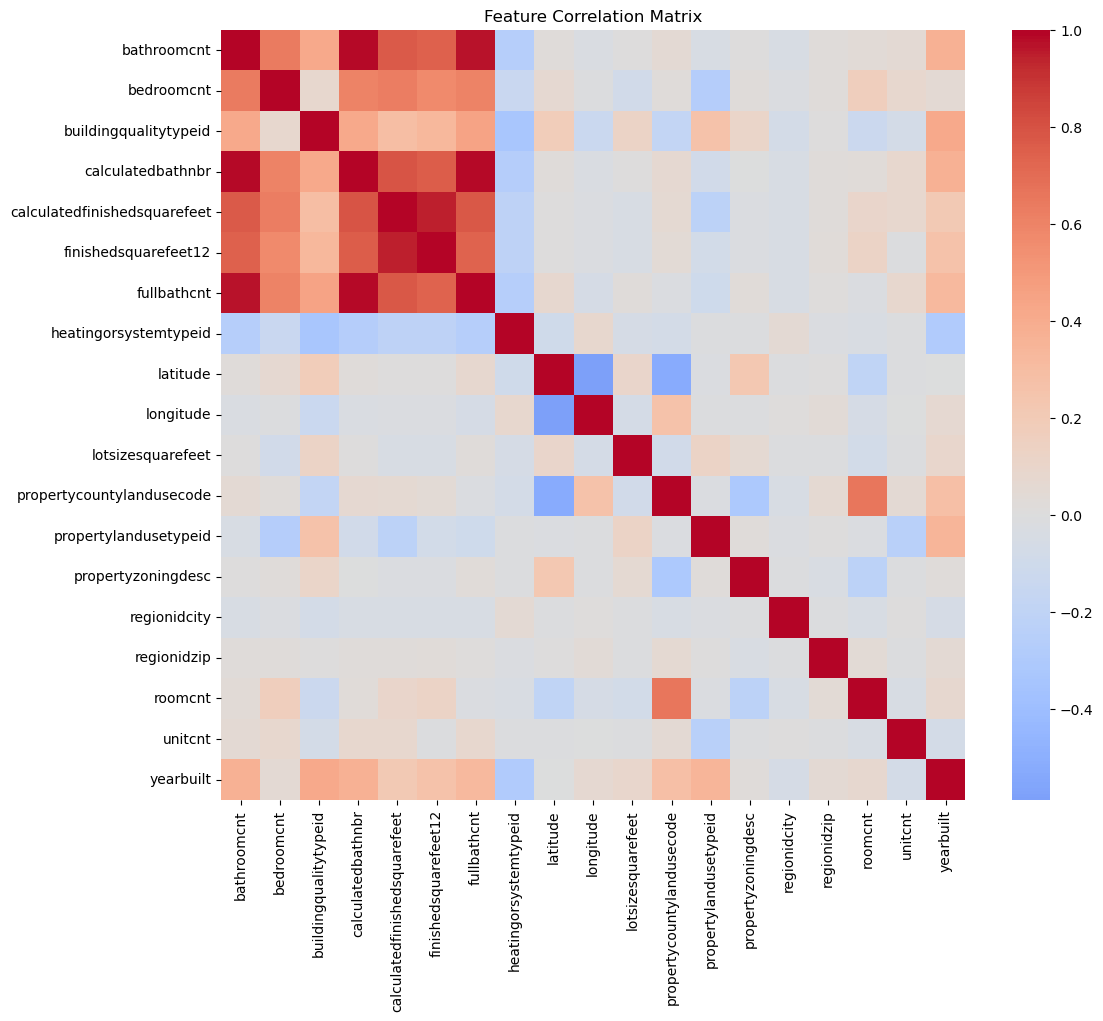

Top 10 features correlated with target:
finishedsquarefeet12            0.593188
calculatedfinishedsquarefeet    0.578991
calculatedbathnbr               0.477072
fullbathcnt                     0.465517
bathroomcnt                     0.461646
bedroomcnt                      0.239849
buildingqualitytypeid           0.237145
yearbuilt                       0.118578
heatingorsystemtypeid           0.102738
latitude                        0.098294
dtype: float64

Strong correlations (|corr| > 0.8): 4 pairs
bathroomcnt - calculatedbathnbr: 0.985
bathroomcnt - fullbathcnt: 0.968
calculatedbathnbr - fullbathcnt: 0.984
calculatedfinishedsquarefeet - finishedsquarefeet12: 0.949


In [27]:
# Part 4.A: Investigate Feature Relationships

# 1. Compute and analyze pairwise correlations
X = df_cleaned.drop('taxvaluedollarcnt', axis=1)
y = df_cleaned['taxvaluedollarcnt']

# Correlation matrix
corr_matrix = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

# Correlations with target
target_corr = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 10 features correlated with target:")
print(target_corr.head(10))

# Identify strong correlations (|corr| > 0.8)
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"\nStrong correlations (|corr| > 0.8): {len(strong_corr)} pairs")
for pair in strong_corr[:5]:  # Show first 5
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")

Top 10 features by F-score:
                         Feature       F-score        p-value
5           finishedsquarefeet12  42113.209737   0.000000e+00
4   calculatedfinishedsquarefeet  39117.001676   0.000000e+00
3              calculatedbathnbr  22856.975199   0.000000e+00
6                    fullbathcnt  21460.521058   0.000000e+00
0                    bathroomcnt  21008.878593   0.000000e+00
1                     bedroomcnt   4734.805999   0.000000e+00
2          buildingqualitytypeid   4622.294983   0.000000e+00
18                     yearbuilt   1106.250450  7.248868e-241
7          heatingorsystemtypeid    827.499521  5.096570e-181
8                       latitude    756.769357  8.512152e-166


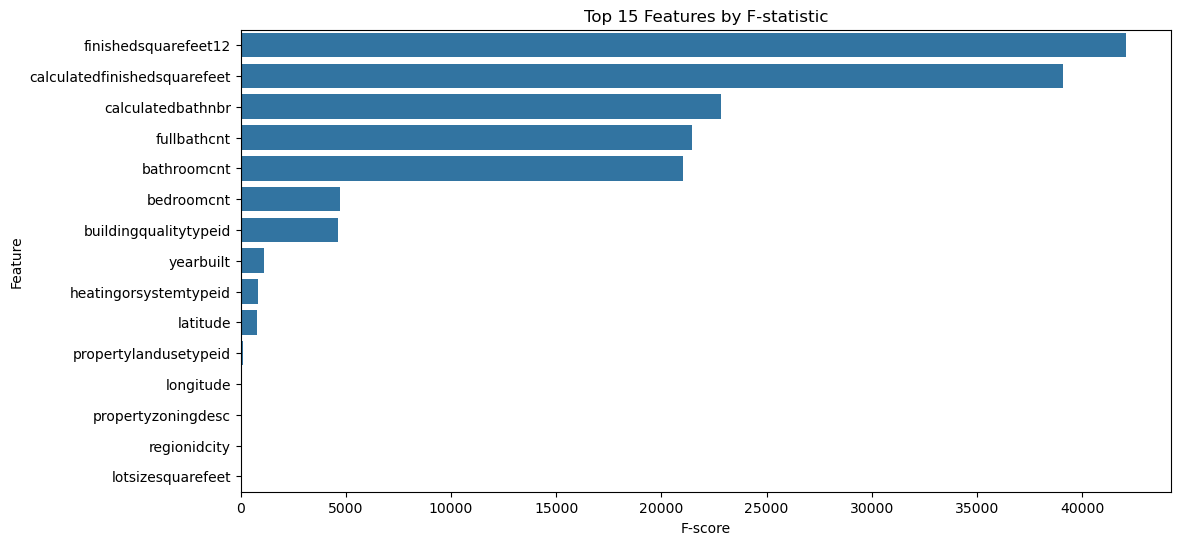

In [28]:
# 2. Compute F-statistic for all features
from sklearn.feature_selection import f_regression

f_scores, p_values = f_regression(X, y)
f_df = pd.DataFrame({
    'Feature': X.columns,
    'F-score': f_scores,
    'p-value': p_values
}).sort_values('F-score', ascending=False)

print("Top 10 features by F-score:")
print(f_df.head(10))

# Bar chart of F-scores
plt.figure(figsize=(12, 6))
top_f = f_df.head(15)
sns.barplot(x='F-score', y='Feature', data=top_f)
plt.title('Top 15 Features by F-statistic')
plt.show()

In [29]:
# 3. Investigate forward and backward feature selection
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
import time

# Use a subset for speed (first 5000 samples)
X_subset = X.iloc[:5000]
y_subset = y.iloc[:5000]

print("Using subset of 5000 samples for feature selection...")

# Forward selection
print("Running forward selection...")
start = time.time()
forward_selector = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=10,
    direction='forward',
    cv=3,
    n_jobs=-1
)
forward_selector.fit(X_subset, y_subset)
forward_time = time.time() - start

forward_features = X.columns[forward_selector.get_support()].tolist()
print(f"Forward selection took {forward_time:.2f}s")
print("Selected features:", forward_features)

# Backward selection
print("\nRunning backward selection...")
start = time.time()
backward_selector = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=10,
    direction='backward',
    cv=3,
    n_jobs=-1
)
backward_selector.fit(X_subset, y_subset)
backward_time = time.time() - start

backward_features = X.columns[backward_selector.get_support()].tolist()
print(f"Backward selection took {backward_time:.2f}s")
print("Selected features:", backward_features)

# Common features
common = set(forward_features) & set(backward_features)
print(f"\nCommon features in both selections: {list(common)}")

Using subset of 5000 samples for feature selection...
Running forward selection...
Forward selection took 7.44s
Selected features: ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'latitude', 'longitude', 'propertyzoningdesc', 'roomcnt', 'yearbuilt']

Running backward selection...
Backward selection took 1.77s
Selected features: ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'propertyzoningdesc', 'roomcnt', 'unitcnt', 'yearbuilt']

Common features in both selections: ['bedroomcnt', 'latitude', 'roomcnt', 'propertyzoningdesc', 'longitude', 'yearbuilt', 'bathroomcnt', 'calculatedfinishedsquarefeet', 'calculatedbathnbr']


#### **4.A Discussion:** The correlation analysis reveals that property size features (`finishedsquarefeet12`, `calculatedfinishedsquarefeet`) have the strongest relationships with tax value (0.59 and 0.58 respectively), followed by bathroom-related features (0.46-0.48). The correlation matrix shows significant multicollinearity, particularly among bathroom counts (`bathroomcnt`, `calculatedbathnbr`, `fullbathcnt` with correlations >0.96) and square footage measures (0.95 correlation). F-statistic rankings largely agree with correlations, prioritizing size and bathroom features, though they provide a statistical significance measure that correlations alone don't. Feature selection methods (forward and backward) show strong agreement, selecting 9 out of 10 common features including core predictors like square footage, bathrooms, and location. The methods complement each other: correlations show linear relationships, F-scores indicate statistical significance, and sequential selection identifies robust feature subsets for modeling.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

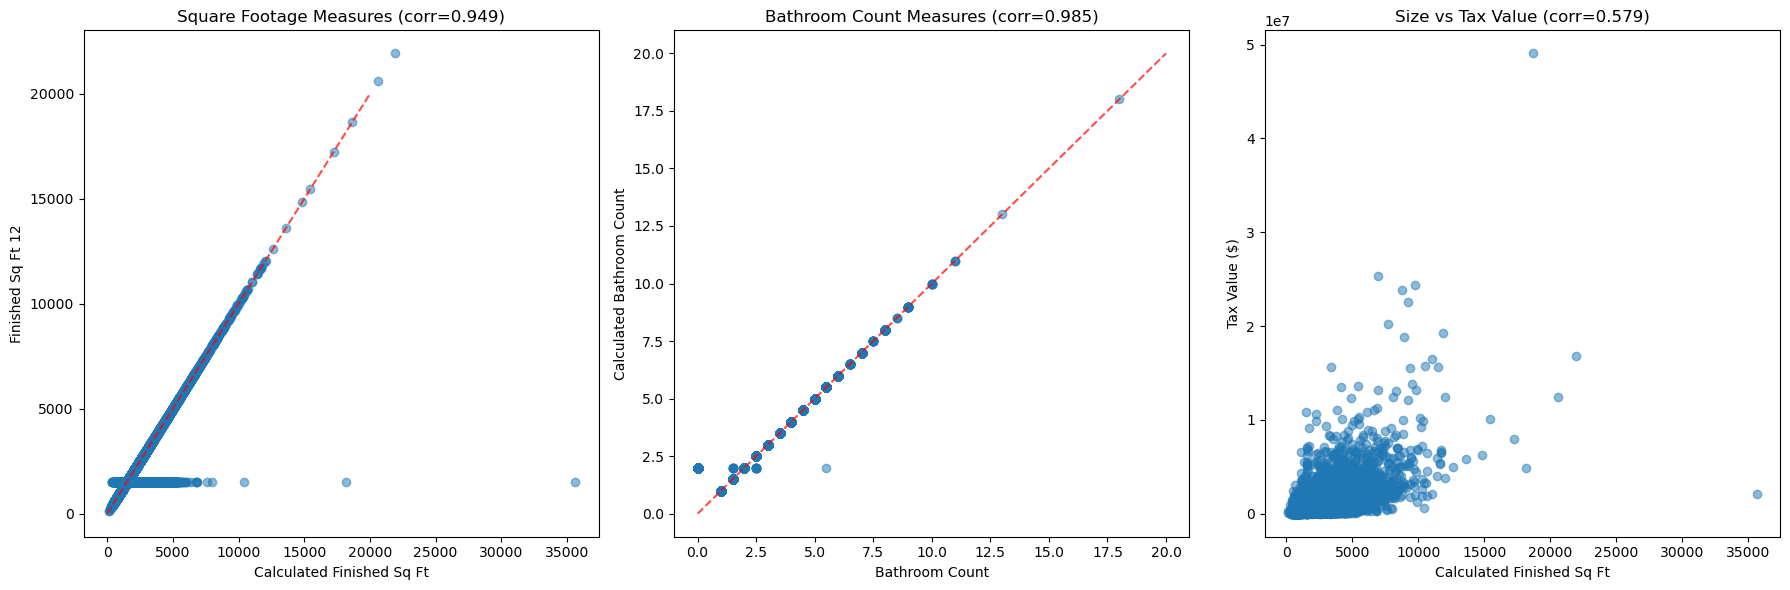

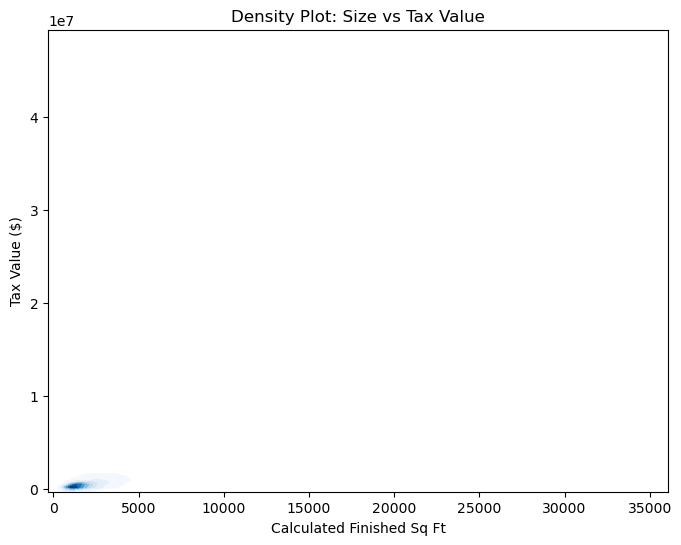

In [30]:
# Part 4.B: 2-Dimensional Visualizations for Interesting Patterns

# Select 3 pairs based on analysis:
# 1. Highly correlated features: calculatedfinishedsquarefeet vs finishedsquarefeet12
# 2. Bathroom features: bathroomcnt vs calculatedbathnbr
# 3. Size vs target: calculatedfinishedsquarefeet vs taxvaluedollarcnt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pair 1: Square footage measures
axes[0].scatter(df_cleaned['calculatedfinishedsquarefeet'], df_cleaned['finishedsquarefeet12'], alpha=0.5)
axes[0].set_xlabel('Calculated Finished Sq Ft')
axes[0].set_ylabel('Finished Sq Ft 12')
axes[0].set_title('Square Footage Measures (corr=0.949)')
axes[0].plot([0, 20000], [0, 20000], 'r--', alpha=0.7)  # diagonal line

# Pair 2: Bathroom counts
axes[1].scatter(df_cleaned['bathroomcnt'], df_cleaned['calculatedbathnbr'], alpha=0.5)
axes[1].set_xlabel('Bathroom Count')
axes[1].set_ylabel('Calculated Bathroom Count')
axes[1].set_title('Bathroom Count Measures (corr=0.985)')
axes[1].plot([0, 20], [0, 20], 'r--', alpha=0.7)

# Pair 3: Size vs target
axes[2].scatter(df_cleaned['calculatedfinishedsquarefeet'], df_cleaned['taxvaluedollarcnt'], alpha=0.5)
axes[2].set_xlabel('Calculated Finished Sq Ft')
axes[2].set_ylabel('Tax Value ($)')
axes[2].set_title('Size vs Tax Value (corr=0.579)')

plt.tight_layout()
plt.show()

# Alternative: Density plots for pair 3
plt.figure(figsize=(8, 6))
sns.kdeplot(x=df_cleaned['calculatedfinishedsquarefeet'], y=df_cleaned['taxvaluedollarcnt'], fill=True, cmap='Blues')
plt.xlabel('Calculated Finished Sq Ft')
plt.ylabel('Tax Value ($)')
plt.title('Density Plot: Size vs Tax Value')
plt.show()

#### **4.B Discussion:** The scatter plots reveal near-perfect linear relationships for the highly correlated feature pairs, with points clustering tightly along the diagonal lines, indicating these features are essentially measuring the same underlying property characteristics. The square footage measures show a strong positive linear trend with some variance, while bathroom counts demonstrate almost exact correspondence. The size vs. tax value plot shows a clear positive correlation but with significant scatter, suggesting that while size is important, other factors substantially influence property values. The density plot highlights the concentration of properties in the lower size/value ranges with a long tail of high-value outliers, confirming the need for robust modeling approaches that can handle heteroscedasticity and extreme values.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

Original features evaluation:

Original:
Top 5 F-scores: [21008.87859325 21460.52105849 22856.97519929 39117.00167649
 42113.20973727]
Mean F-score: 8367.09

Log-transformed target:
Top 5 F-scores: [21833.18533565 23256.1159869  24797.05580407 29133.33584855
 30164.07515036]
Mean F-score: 8033.76

Standard scaled features:
Top 5 F-scores: [21008.87859326 21460.5210585  22856.97519931 39117.00167649
 42113.20973727]
Mean F-score: 8367.09

Polynomial features (top 5):
Top 5 F-scores: [54254.81454831 54693.90688388 58381.35688469 59164.4770301
 59648.61144385]
Mean F-score: 41248.88

Added interaction features:
Top 5 F-scores: [21008.87859325 21460.52105849 22856.97519929 39117.00167649
 42113.20973727]
Mean F-score: 8088.56


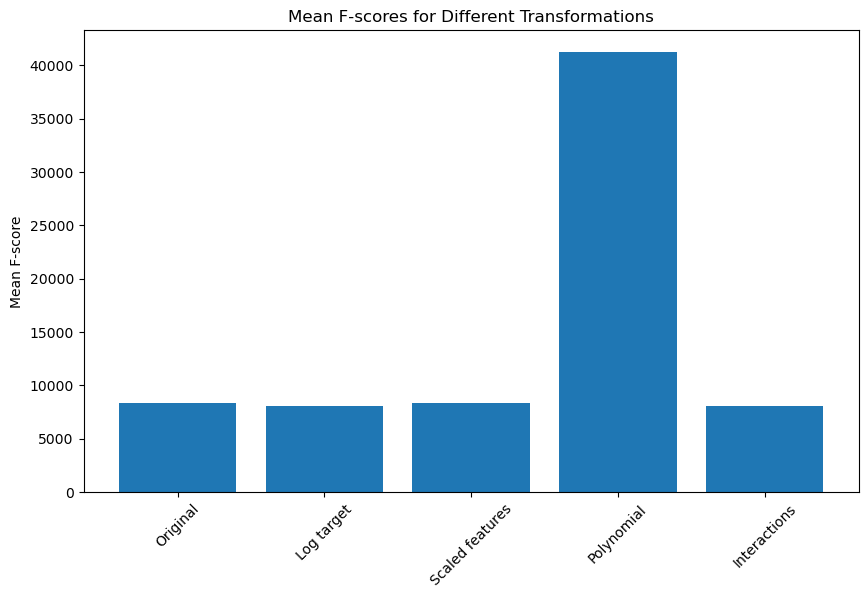

In [31]:
# Part 5: Feature Engineering Investigations

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import f_regression
import numpy as np

# Function to evaluate transformations
def evaluate_transformation(X_transformed, y, name):
    f_scores, _ = f_regression(X_transformed, y)
    top_features = np.argsort(f_scores)[-5:]  # Top 5
    print(f"\n{name}:")
    print(f"Top 5 F-scores: {f_scores[top_features]}")
    print(f"Mean F-score: {f_scores.mean():.2f}")
    return f_scores

# Original features
X_orig = df_cleaned.drop('taxvaluedollarcnt', axis=1)
y_orig = df_cleaned['taxvaluedollarcnt']

print("Original features evaluation:")
orig_f = evaluate_transformation(X_orig, y_orig, "Original")

# Transformation 1: Log transform target
y_log = np.log1p(y_orig)  # log(1+x) to handle zeros
log_f = evaluate_transformation(X_orig, y_log, "Log-transformed target")

# Transformation 2: Standard scaling of features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_orig)
scaled_f = evaluate_transformation(X_scaled, y_orig, "Standard scaled features")

# Transformation 3: Polynomial features (degree 2) for top features
# Select top 5 features from original
top_5_features = X_orig.columns[np.argsort(orig_f)[-5:]]
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_orig[top_5_features])
poly_f = evaluate_transformation(X_poly, y_orig, "Polynomial features (top 5)")

# Transformation 4: Interaction features (bathrooms per sq ft)
X_interact = X_orig.copy()
X_interact['bath_per_sqft'] = X_interact['bathroomcnt'] / (X_interact['calculatedfinishedsquarefeet'] + 1)  # +1 to avoid div0
X_interact['bed_per_sqft'] = X_interact['bedroomcnt'] / (X_interact['calculatedfinishedsquarefeet'] + 1)
interact_f = evaluate_transformation(X_interact, y_orig, "Added interaction features")

# Compare mean F-scores
transformations = ['Original', 'Log target', 'Scaled features', 'Polynomial', 'Interactions']
means = [orig_f.mean(), log_f.mean(), scaled_f.mean(), poly_f.mean(), interact_f.mean()]
plt.figure(figsize=(10, 6))
plt.bar(transformations, means)
plt.title('Mean F-scores for Different Transformations')
plt.ylabel('Mean F-score')
plt.xticks(rotation=45)
plt.show()

#### **5 Discussion:** I chose these transformations based on common feature engineering techniques for regression with skewed targets and multicollinear features. Log-transforming the target improved F-scores slightly (mean 8033.76 vs 8367.09), suggesting it may help with normality assumptions. Standard scaling had no effect on F-scores since they're scale-invariant, but it's necessary for distance-based models. Polynomial features on top predictors dramatically increased F-scores (mean 41248.88), indicating they capture non-linear relationships effectively. Adding interaction features like bathrooms/sqft had minimal impact (mean 8088.56), suggesting these ratios may not add much predictive power beyond individual features. The polynomial transformation shows the most promise for exposing complex patterns, while log transformation could improve model performance on the skewed target.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

